# Handwritten Digits Classifier in Pytorch
---

Project #1 of the Udacity Deep Learning Nanodegree

Author: **Roberto Fierimonte**

In [1]:
%load_ext autoreload
%autoreload 2

In [2]:
from datetime import datetime, timezone
from pathlib import Path

import matplotlib
import matplotlib.figure
import matplotlib.pyplot as plt
import numpy as np
import torch
import torch.nn as nn
import torch.nn.functional as F
import torch.optim as optim
import torchvision.transforms.functional as tF
from loguru import logger
from torch import Tensor
from torch.utils.data import DataLoader, random_split
from torch.utils.tensorboard import SummaryWriter
from torchinfo import summary
from torchvision import datasets, transforms, utils

In [3]:
# Neural Network models
class DenseNet(nn.Module):
    """Class for a fully connected neural network."""

    def __init__(self):
        super().__init__()
        self.dropout = nn.Dropout(p=0.5)
        self.fc1 = nn.Linear(784, 120)
        self.fc2 = nn.Linear(120, 84)
        self.fc3 = nn.Linear(84, 10)

    def forward(self, x: torch.Tensor) -> torch.Tensor:
        """Compute a forward pass step.

        Args:
            x (torch.Tensor): Input data to the network.

        Returns:
            torch.Tensor: Output data to the network.
        """
        x = torch.flatten(x, start_dim=1)  # Flatten all dimensions except batch
        x = F.relu(self.fc1(x))
        x = self.dropout(x)
        x = F.relu(self.fc2(x))
        x = self.dropout(x)
        x = self.fc3(x)
        return x


class Lenet5(nn.Module):
    """Class for the LeNet5 neural network."""

    def __init__(self):
        super().__init__()
        self.conv1 = nn.Conv2d(
            in_channels=1, out_channels=6, kernel_size=(5, 5), padding=(2, 2)
        )
        self.pool1 = nn.AvgPool2d(kernel_size=(2, 2), stride=(2, 2))
        self.conv2 = nn.Conv2d(in_channels=6, out_channels=16, kernel_size=(5, 5))
        self.pool2 = nn.AvgPool2d(kernel_size=(2, 2), stride=(2, 2))
        self.dense1 = nn.Linear(in_features=400, out_features=120)
        self.dense2 = nn.Linear(in_features=120, out_features=84)
        self.output = nn.Linear(in_features=84, out_features=10)

    def forward(self, x: torch.Tensor) -> torch.Tensor:
        """Compute a forward pass step.

        Args:
            x (torch.Tensor): Input data to the network.

        Returns:
            torch.Tensor: Output data to the network.
        """
        x = self.conv1(x)
        x = F.relu(self.pool1(x))
        x = self.conv2(x)
        x = F.relu(self.pool2(x))
        x = torch.flatten(x, start_dim=1)
        x = F.relu(self.dense1(x))
        x = F.relu(self.dense2(x))
        x = self.output(x)
        return x

In [ ]:
# Utility functions
# Some code is adapted from: https://pytorch.org/tutorials/intermediate/tensorboard_tutorial.html

def show_grid(imgs: list[Tensor] | Tensor) -> None:
    """Show a grid of images using matplotlib.

    Args:
        imgs (list[Tensor] | Tensor): Image tensor with shape N x C x H x W, or list
            of len N of tensors with shape C x H x W.
    """
    if not isinstance(imgs, list):
        imgs = [imgs]

    _, axs = plt.subplots(ncols=len(imgs), squeeze=False)
    for i, img in enumerate(imgs):
        img = img.detach()
        img = tF.to_pil_image(img)
        axs[0, i].imshow(np.asarray(img))
        axs[0, i].set(xticklabels=[], yticklabels=[], xticks=[], yticks=[])


def _matplotlib_imshow(img: Tensor) -> None:
    """Plot an image tensor using matplotlib.

    Args:
        img (Tensor): Image tensor with shape C x H x W.
    """
    npimg = img.numpy()
    plt.imshow(npimg, cmap="Greys")


def _images_to_probs(net: nn.Module, images: Tensor) -> tuple[np.ndarray, list[float]]:
    """Generates predictions and probabilities from a trained network and a list of images.

    Args:
        net (nn.Module): The model used to generate the predictions.
        images (Tensor): Image tensor with shape N x C x H x W.

    Returns:
        np.ndarray: Array (N,) of model predictions.
        list[float]: List of len N of probabilities for the predicted class.
    """
    output = net(images)

    # Convert output probabilities to predicted class
    _, preds_tensor = torch.max(output, 1)
    preds = np.squeeze(preds_tensor.numpy())
    return preds, [F.softmax(el, dim=0)[i].item() for i, el in zip(preds, output)]


def plot_classes_preds(
    net: nn.Module, images: Tensor, labels: Tensor, classes: list
) -> matplotlib.figure.Figure:
    """Generate a plot of images together with real and predicted classes.

    Generates a matplotlib Figure using a trained network, along with images
    and labels from a batch, that shows the network's top prediction along
    with its probability, alongside the actual label, colouring this
    information based on whether the prediction was correct or not.

    Args:
        net (nn.Module): Model used to generate the predictions.
        images (Tensor): Image tensor with shape N x H x W.
        labels (Tensor): Targer tensor with shape N
        classes (list): List of len T of all unique image labels.

    Returns:
        matplotlib.figure.Figure: Plot of images with corresponding ground truth and
            predicted labels.
    """
    # Shuffle the data before plotting
    perm = torch.randperm(labels.shape[0])
    images = images[perm, :, :]
    labels = labels[perm]

    preds, probs = _images_to_probs(net, images[:, None, :, :])

    # Plot the images in the batch, along with predicted and true labels
    # Plot at most 100 images
    ncols = 5
    nplots = min(images.shape[0], 100)
    nrows = int(np.ceil(nplots / ncols))

    fig = plt.figure(figsize=(12, 60))
    for idx in np.arange(nplots):
        ax = fig.add_subplot(nrows, ncols, idx + 1, xticks=[], yticks=[])
        _matplotlib_imshow(images[idx])
        ax.set_title(
            "{0}, {1:.1f}%\n(label: {2})".format(
                classes[preds[idx]], probs[idx] * 100.0, classes[labels[idx]]
            ),
            color=("green" if preds[idx] == labels[idx].item() else "red"),
        )
    return fig

In [5]:
# Notebook setup
data_path = Path.cwd() / "data"
runs_path = Path.cwd() / "runs"

Path.mkdir(data_path, exist_ok=True)
Path.mkdir(runs_path, exist_ok=True)

## Step 1: Data loading and exploration

As a first step we load, display, and analyse the raw training data. Here we do not perform any transformation to the data apart from coverting images to tensors.

In [6]:
if torch.cuda.is_available():
    device = "cuda"
elif torch.backends.mps.is_available():
    device = "mps"
else:
    device = "cpu"
device = torch.device(device)

logger.info(f"Using {device} device.")

2025-01-04 23:36:11.143 | INFO     | __main__:<module>:9 - Using cpu device.


In [7]:
raw_data = datasets.MNIST(
    data_path, download=True, train=True, transform=transforms.ToTensor()
)
raw_loader = DataLoader(raw_data, batch_size=16)

Failed to download (trying next):
HTTP Error 403: Forbidden



100.0%


Extracting /home/robertofierimonte/projects/udacity-deep-learning/data/MNIST/raw/train-images-idx3-ubyte.gz to /home/robertofierimonte/projects/udacity-deep-learning/data/MNIST/raw

Failed to download (trying next):
HTTP Error 403: Forbidden



100.0%


Extracting /home/robertofierimonte/projects/udacity-deep-learning/data/MNIST/raw/train-labels-idx1-ubyte.gz to /home/robertofierimonte/projects/udacity-deep-learning/data/MNIST/raw

Failed to download (trying next):
HTTP Error 403: Forbidden



100.0%


Extracting /home/robertofierimonte/projects/udacity-deep-learning/data/MNIST/raw/t10k-images-idx3-ubyte.gz to /home/robertofierimonte/projects/udacity-deep-learning/data/MNIST/raw

Failed to download (trying next):
HTTP Error 403: Forbidden



100.0%

Extracting /home/robertofierimonte/projects/udacity-deep-learning/data/MNIST/raw/t10k-labels-idx1-ubyte.gz to /home/robertofierimonte/projects/udacity-deep-learning/data/MNIST/raw



2025-01-04 23:36:21.815 | INFO     | __main__:<module>:1 - Number of samples: 60000.
2025-01-04 23:36:21.815 | INFO     | __main__:<module>:2 - Number of classes: 10.
2025-01-04 23:36:21.816 | INFO     | __main__:<module>:3 - Classes: ['0 - zero', '1 - one', '2 - two', '3 - three', '4 - four', '5 - five', '6 - six', '7 - seven', '8 - eight', '9 - nine'].
2025-01-04 23:36:21.824 | INFO     | __main__:<module>:6 - Shape of batch: (16, 1, 28, 28).
2025-01-04 23:36:21.826 | INFO     | __main__:<module>:7 - Min pixel value: 0.0, max pixel value: 1.0.


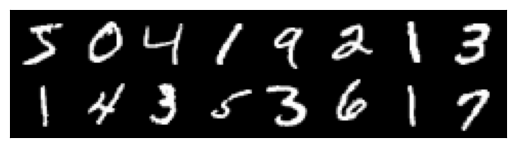

In [8]:
logger.info(f"Number of samples: {len(raw_data)}.")
logger.info(f"Number of classes: {len(raw_data.classes)}.")
logger.info(f"Classes: {raw_data.classes}.")

raw_batch = next(iter(raw_loader))[0]
logger.info(f"Shape of batch: {tuple(raw_batch.shape)}.")
logger.info(
    f"Min pixel value: {raw_batch.min().item()}, max pixel value: {raw_batch.max().item()}."
)

raw_grid = utils.make_grid(next(iter(raw_loader))[0])
show_grid(raw_grid)

As we can observe, the images are 28 x 28 pixels in size, and they have a single channel. The pixel values are also already normalised between 0 and 1.

Based on the fact that we want to classify handwritten digits, we can now think to some data augmentation transformations that we can apply to the training set. The transformations that have identified are:
- Random invert: Flips the value of a pixel with probability 0.2. This makes the model less sensitive to the actual value of a pixel but more to how the pixel intensity changes (matters more for MLPs than for CNNs).
- Random rotation: Rotates the image between -10 and 10 degrees. This makes the model less sensitive to the direction in which the number is drawn.
- Random perspective: Introduces a distortion in the image perspective with probability 0.2. This makes the model less sensitive to extreme distorted numbers.

**N.B.:** We should not apply these transformation to the testing and validation sets, as the model performance needs to be assessed on the original image space.

## Step 2: Model design and training

You can change the parameters below to tweak the experiment settings. The parameters will be saved in Tensorboard together with the results of the experimet.

In [9]:
# Experiment configuration
batch_size = 32  # Batch size
n_epochs = 10  # Number of training epochs
model = "lenet5"  # Model type

if model not in ["densenet", "lenet5"]:
    raise RuntimeError("The model type must be one of ['densenet', 'lenet5'].")

In [10]:
run_name = datetime.now(timezone.utc).strftime("%Y%m%dT%H%M%S")
run_path = runs_path / run_name

writer = SummaryWriter(run_path)

In [11]:
train_transform = transforms.Compose(
    [
        transforms.ToTensor(),
        transforms.RandomInvert(p=0.2),
        transforms.RandomRotation(degrees=(-10, 10), expand=False),
        transforms.RandomPerspective(distortion_scale=0.3, p=0.2),
    ]
)
train_data = datasets.MNIST(
    data_path, download=True, train=True, transform=train_transform
)
train_loader = DataLoader(train_data, batch_size=batch_size)

In [12]:
test_val_data = datasets.MNIST(
    data_path, download=True, train=False, transform=transforms.ToTensor()
)
test_val_generator = torch.Generator().manual_seed(
    42
)  # We fix the train / test split across multiple runs
test_data, val_data = random_split(
    test_val_data, lengths=[0.5, 0.5], generator=test_val_generator
)

test_loader = DataLoader(test_data, batch_size=batch_size, shuffle=True)
val_loader = DataLoader(val_data, batch_size=batch_size, shuffle=True)

2025-01-04 23:36:22.049 | INFO     | __main__:<module>:1 - Number of training samples: 60000.
2025-01-04 23:36:22.050 | INFO     | __main__:<module>:2 - Number of validation samples: 5000.
2025-01-04 23:36:22.051 | INFO     | __main__:<module>:3 - Number of test samples: 5000.


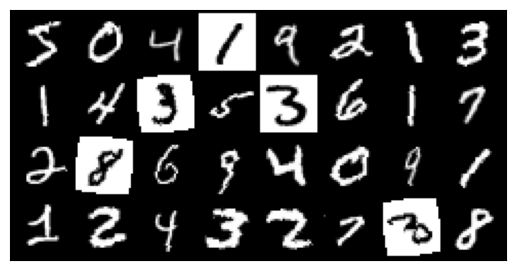

In [13]:
logger.info(f"Number of training samples: {len(train_data)}.")
logger.info(f"Number of validation samples: {len(val_data)}.")
logger.info(f"Number of test samples: {len(test_data)}.")

train_grid = utils.make_grid(next(iter(train_loader))[0])
show_grid(train_grid)

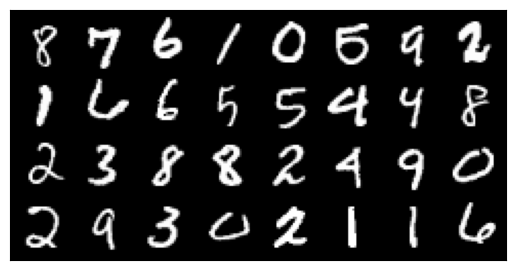

In [14]:
test_grid = utils.make_grid(next(iter(test_loader))[0])
show_grid(test_grid)

In [15]:
if model == "densenet":
    net = DenseNet()
else:
    net = Lenet5()
net.to(device)

Lenet5(
  (conv1): Conv2d(1, 6, kernel_size=(5, 5), stride=(1, 1), padding=(2, 2))
  (pool1): AvgPool2d(kernel_size=(2, 2), stride=(2, 2), padding=0)
  (conv2): Conv2d(6, 16, kernel_size=(5, 5), stride=(1, 1))
  (pool2): AvgPool2d(kernel_size=(2, 2), stride=(2, 2), padding=0)
  (dense1): Linear(in_features=400, out_features=120, bias=True)
  (dense2): Linear(in_features=120, out_features=84, bias=True)
  (output): Linear(in_features=84, out_features=10, bias=True)
)

In [16]:
summary(net, input_size=[batch_size, 1, 28, 28])

Layer (type:depth-idx)                   Output Shape              Param #
Lenet5                                   [32, 10]                  --
├─Conv2d: 1-1                            [32, 6, 28, 28]           156
├─AvgPool2d: 1-2                         [32, 6, 14, 14]           --
├─Conv2d: 1-3                            [32, 16, 10, 10]          2,416
├─AvgPool2d: 1-4                         [32, 16, 5, 5]            --
├─Linear: 1-5                            [32, 120]                 48,120
├─Linear: 1-6                            [32, 84]                  10,164
├─Linear: 1-7                            [32, 10]                  850
Total params: 61,706
Trainable params: 61,706
Non-trainable params: 0
Total mult-adds (Units.MEGABYTES): 13.54
Input size (MB): 0.10
Forward/backward pass size (MB): 1.67
Params size (MB): 0.25
Estimated Total Size (MB): 2.02

In [17]:
# Define the loss function (cross-entropy loss) and the optimizer
if model == "densenet":
    optimizer = optim.SGD(net.parameters(), lr=0.01, momentum=0.9, weight_decay=1e-5)
else:
    optimizer = optim.Adam(net.parameters(), lr=0.001)
criterion = nn.CrossEntropyLoss()

In [18]:
# Train the Neural Network
train_loss_history = list()
val_loss_history = list()

writer.add_scalar("Batch size", batch_size)
writer.add_text("Model type", model)
writer.add_image("Train images", train_grid)
writer.add_image("Test images", test_grid)

for epoch in range(n_epochs):
    net.train()
    train_loss = 0.0
    train_correct = 0
    for i, data in enumerate(train_loader):
        # Data is a list of [inputs, labels]
        inputs, labels = data

        # Pass to GPU if available.
        inputs, labels = inputs.to(device), labels.to(device)

        # Log the model during the first iteration
        if epoch == 0:
            writer.add_graph(net, inputs)

        optimizer.zero_grad()

        outputs = net(inputs)
        loss = criterion(outputs, labels)
        loss.backward()
        optimizer.step()

        _, preds = torch.max(outputs.data, 1)
        train_correct += (preds == labels).float().mean().item()
        train_loss += loss.item()

    # Log the training stats
    writer.add_scalar("Loss/train", train_loss / len(train_loader), epoch + 1)
    writer.add_scalar("Accuracy/train", train_correct / len(train_loader), epoch + 1)
    logger.info(
        f"Epoch {epoch + 1} training accuracy: {train_correct / len(train_loader):.2%} "
        f"training loss: {train_loss / len(train_loader):.5f}."
    )
    train_loss_history.append(train_loss / len(train_loader))

    val_loss = 0.0
    val_correct = 0.0
    net.eval()
    for inputs, labels in val_loader:
        inputs, labels = inputs.to(device), labels.to(device)

        outputs = net(inputs)
        loss = criterion(outputs, labels)

        _, preds = torch.max(outputs.data, 1)
        val_correct += (preds == labels).float().mean().item()
        val_loss += loss.item()

    # Log the validation stats
    writer.add_scalar("Loss/valid", val_loss / len(val_loader), epoch + 1)
    writer.add_scalar("Accuracy/valid", val_correct / len(val_loader), epoch + 1)
    logger.info(
        f"Epoch {epoch + 1} validation accuracy: {val_correct / len(val_loader):.2%} "
        f"validation loss: {val_loss / len(val_loader):.5f}."
    )
    val_loss_history.append(val_loss / len(val_loader))

2025-01-04 23:38:10.600 | INFO     | __main__:<module>:39 - Epoch 1 training accuracy: 84.32% training loss: 0.49059.
2025-01-04 23:38:11.244 | INFO     | __main__:<module>:61 - Epoch 1 validation accuracy: 95.16% validation loss: 0.14842.
2025-01-04 23:38:46.577 | INFO     | __main__:<module>:39 - Epoch 2 training accuracy: 93.42% training loss: 0.21035.
2025-01-04 23:38:47.123 | INFO     | __main__:<module>:61 - Epoch 2 validation accuracy: 96.36% validation loss: 0.11037.
2025-01-04 23:39:21.149 | INFO     | __main__:<module>:39 - Epoch 3 training accuracy: 95.08% training loss: 0.15933.
2025-01-04 23:39:21.711 | INFO     | __main__:<module>:61 - Epoch 3 validation accuracy: 96.88% validation loss: 0.09436.
2025-01-04 23:40:05.681 | INFO     | __main__:<module>:39 - Epoch 4 training accuracy: 95.85% training loss: 0.13395.
2025-01-04 23:40:06.170 | INFO     | __main__:<module>:61 - Epoch 4 validation accuracy: 97.21% validation loss: 0.08311.
2025-01-04 23:40:39.689 | INFO     | __m

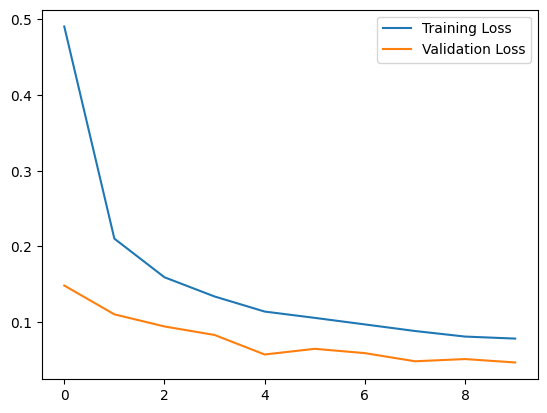

In [19]:
# Plot the training and validation loss history
plt.plot(train_loss_history, label="Training Loss")
plt.plot(val_loss_history, label="Validation Loss")
plt.legend()
plt.show()

In [20]:
# Save the model parameters
torch.save(net.state_dict(), run_path / "model.pt")

## Step 3: Model testing and evaluation

In [21]:
# Evaluate the Neural Network on the test set
test_loss = 0.0
test_correct = 0.0
net.eval()
for inputs, labels in test_loader:
    inputs, labels = inputs.to(device), labels.to(device)

    outputs = net(inputs)
    loss = criterion(outputs, labels)

    _, preds = torch.max(outputs.data, 1)
    test_correct += (preds == labels).float().mean().item()
    test_loss += loss.item()

# Log the test stats
writer.add_scalar("Loss/test", test_loss / len(test_loader), n_epochs)
writer.add_scalar("Accuracy/test", test_correct / len(test_loader), n_epochs)
logger.info(
    f"Test accuracy: {test_correct / len(test_loader):.2%} "
    f"test loss: {test_loss / len(test_loader):.5f}."
)

2025-01-04 23:43:46.497 | INFO     | __main__:<module>:18 - Test accuracy: 98.87% test loss: 0.03486.


In [22]:
# Move the network to the CPU for plotting the predictions vs actuals
net.to("cpu")

Lenet5(
  (conv1): Conv2d(1, 6, kernel_size=(5, 5), stride=(1, 1), padding=(2, 2))
  (pool1): AvgPool2d(kernel_size=(2, 2), stride=(2, 2), padding=0)
  (conv2): Conv2d(6, 16, kernel_size=(5, 5), stride=(1, 1))
  (pool2): AvgPool2d(kernel_size=(2, 2), stride=(2, 2), padding=0)
  (dense1): Linear(in_features=400, out_features=120, bias=True)
  (dense2): Linear(in_features=120, out_features=84, bias=True)
  (output): Linear(in_features=84, out_features=10, bias=True)
)

In [23]:
test_actuals_preds = plot_classes_preds(
    net=net,
    images=test_data.dataset.data.float(),
    labels=test_data.dataset.targets,
    classes=test_data.dataset.classes,
)
writer.add_figure("Test/predictions vs actuals", test_actuals_preds, n_epochs)

In [24]:
# Close the tensorboard writer
writer.flush()
writer.close()